# (Opsiyonal) Olist reviews' - Translations...

* 🇧🇷 Brezilya Portekizcesi bilmiyorsanız, hadi `order_reviews` metinlerini 🇬🇧 İngilizce’ye çevirelim!

* Bunun için `pip install googletrans==4.0.2` yüklemeniz gerekecek.

☢️ Bu API ile herhangi bir sorun yaşarsanız, bunu düzeltmek için zaman harcamayın, bu package oldukça dengesiz… Aklınızda bulunsun:
- bu optional bir challenge
- Brezilya Portekizcesi ile yazılmış review’ların anlamını görmek için bazı yorumları Google Translate’e kopyalayıp yapıştırarak yine de eski yöntemle yapabilirsiniz.

## Review Translator

👉 `reviews` dataset’ini load edin ve 1-yıldız rating’e sahip review’lardan bir örnek (sample) seçin.

In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)
texts = [
    "Produto chegou quebrado e atrasado, péssimo serviço.",
    "Não recebi meu pedido até hoje, absurdo!",
    "Produto veio diferente do anunciado, quero reembolso.",
    "Entrega demorou muito mais do que o prazo prometido.",
    "Péssima experiência, vendedor não responde.",
    "Item chegou com defeito, muito insatisfeito.",
    "Nunca mais compro nessa loja, produto de baixa qualidade.",
    "Caixa chegou amassada e produto danificado.", np.nan
]

df = pd.DataFrame({
    'review_score': np.random.choice([1,2,3,4,5], 10000, p=[0.11,0.03,0.08,0.19,0.59]),
    'review_comment_message': np.random.choice(texts, 10000)
})
df.head()

,review_score,review_comment_message
0,4,"Nunca mais compro nessa loja, produto de baixa..."
1,5,Entrega demorou muito mais do que o prazo prom...
2,5,"Não recebi meu pedido até hoje, absurdo!"
3,5,"Péssima experiência, vendedor não responde."
4,3,"Produto veio diferente do anunciado, quero ree..."


👀 20 adet düşük puan alan yorumdan oluşan bir örneklem seçin (rastgele) ve bunu bir listeye dönüştürün.

In [3]:
reviews_list = (df[df['review_score'] == 1]
                .dropna(subset=['review_comment_message'])
                .sample(20, random_state=42)['review_comment_message']
                .tolist())

print(f"Seçilen yorum sayısı: {len(reviews_list)}")

Seçilen yorum sayısı: 20


🗣 Bu göreve başlamadan önce önceden yüklediğiniz `google_translator` paketini kullanarak bu yorumları çevirin:

In [5]:
!pip install deep-translator --break-system-packages -q

from deep_translator import GoogleTranslator

def translate(text):
    try:
        return GoogleTranslator(source='pt', target='en').translate(text)
    except:
        return "[error]"

translations_df = pd.DataFrame({
    'original_text': reviews_list,
    'translated_text': [translate(t) for t in reviews_list]
})
translations_df.head()

,original_text,translated_text
0,"Não recebi meu pedido até hoje, absurdo!","I haven't received my order until today, absurd!"
1,"Não recebi meu pedido até hoje, absurdo!","I haven't received my order until today, absurd!"
2,Caixa chegou amassada e produto danificado.,Box arrived dented and product damaged.
3,"Produto veio diferente do anunciado, quero ree...","Product came different than advertised, I want..."
4,"Nunca mais compro nessa loja, produto de baixa...","I will never buy from this store again, low qu..."


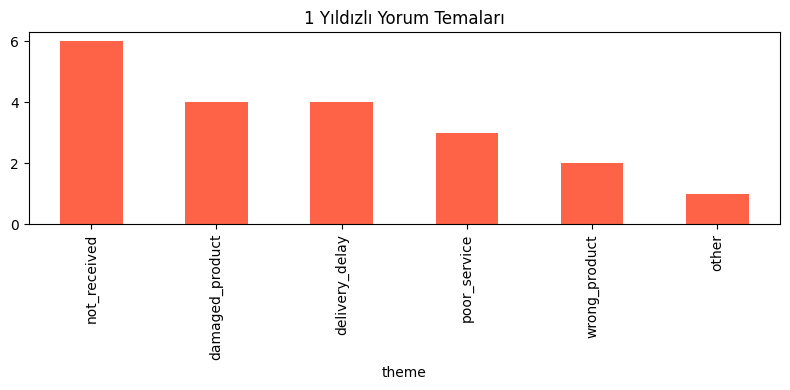

In [6]:
import matplotlib.pyplot as plt

themes = {
    'delivery_delay':  ['delay', 'late', 'wait', 'time'],
    'damaged_product': ['broken', 'damaged', 'defect'],
    'wrong_product':   ['different', 'wrong', 'advertised'],
    'refund_request':  ['refund', 'return', 'money'],
    'not_received':    ['never', 'received', 'missing'],
    'poor_service':    ['seller', 'respond', 'support'],
}

def label_theme(text):
    text = str(text).lower()
    for theme, keywords in themes.items():
        if any(k in text for k in keywords):
            return theme
    return 'other'

translations_df['theme'] = translations_df['translated_text'].apply(label_theme)
translations_df['theme'].value_counts().plot(kind='bar', color='tomato', figsize=(8,4), title='1 Yıldızlı Yorum Temaları')
plt.tight_layout()
plt.show()

**Insights** 💡
- Bazı kötü review’lar delivery ile ilgili (`wait_time`, kaçırılan teslim tarihi, vb.)
- Ancak bazı kötü review’lar seller veya ürünle ilgili...

Peki iki olası nedeni nasıl ayırt edebiliriz?

Bu Olist’in mutlaka bilmesi gereken bir şey:
- bazı ürünleri katalogdan mı çıkarmalı?
- yoksa bazı seller’ları marketplace’ten mi kaldırmalı?
